In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Cross-validation (to show instability)
cv_dt = cross_val_score(dt, X, y, cv=5)
print("Decision Tree CV Scores:", cv_dt)
print("Decision Tree CV Mean:", np.mean(cv_dt))

Decision Tree Accuracy: 0.9473684210526315
Decision Tree CV Scores: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Decision Tree CV Mean: 0.9173420276354604


# Bagging Classifier

In [6]:

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

print("\nBagging Accuracy:", accuracy_score(y_test, y_pred_bag))


Bagging Accuracy: 0.956140350877193


In [7]:
cv_bag = cross_val_score(bag, X, y, cv=5)
print("Bagging CV Scores:", cv_bag)
print("Bagging CV Mean:", np.mean(cv_bag))

Bagging CV Scores: [0.89473684 0.93859649 0.98245614 0.96491228 0.99115044]
Bagging CV Mean: 0.9543704393727681


In [8]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging"],
    "CV Mean Accuracy": [np.mean(cv_dt), np.mean(cv_bag)],
    "CV Std Dev": [np.std(cv_dt), np.std(cv_bag)]
})

print("\nStability Comparison:\n", results)


Stability Comparison:
            Model  CV Mean Accuracy  CV Std Dev
0  Decision Tree          0.917342    0.024195
1        Bagging          0.954370    0.034807


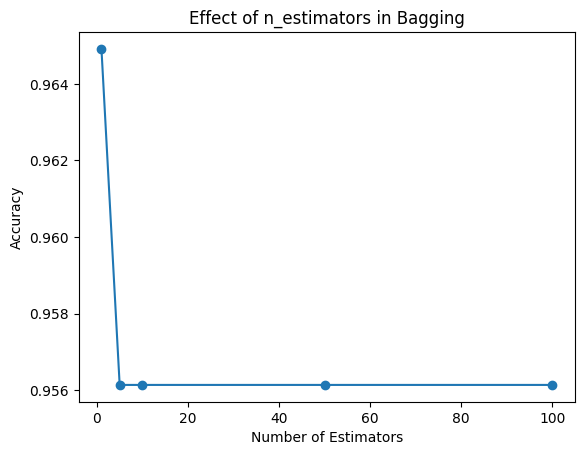

In [9]:
estimators_range = [1, 5, 10, 50, 100]
acc_list = []

for n in estimators_range:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_list.append(accuracy_score(y_test, pred))

plt.plot(estimators_range, acc_list, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Effect of n_estimators in Bagging")
plt.show()